# Leakage Audit

Compare four feature surfaces:
- `full`: current main-branch feature set
- `clean`: `feature_analysis` minus the three high-risk groups (`per_minute_rates`, `player_hero_wr`, `cumulative_counts`)
- `feature_analysis`: reproduce the feature-analysis branch cleanup
- `minimal`: draft + MMR + matches_played lower bound

Use the profile table to check whether the cleaned surface still lands in a plausible range above the `minimal` floor, then run focused ablation on the higher-signal configurations.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from xgboost import XGBClassifier

sys.path.insert(0, str(Path('..').resolve()))
from src.pipeline import (
    ablate_matrix_group,
    feature_group_registry,
    load_with_meta,
    make_feature_frame,
    random_split,
    time_split,
    transform_splits,
    build_pipeline,
)

out_dir = Path('../results')
out_dir.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 40)

In [2]:
data_path = '../data/processed/matches.parquet'
df_base, y, df_meta = load_with_meta(data_path)
feature_frames = {
    'full': make_feature_frame(df_base, y, feature_set='full'),
    'clean': make_feature_frame(df_base, y, feature_set='clean'),
    'feature_analysis': make_feature_frame(df_base, y, feature_set='feature_analysis'),
    'minimal': make_feature_frame(df_base, y, feature_set='minimal'),
}
splits = {
    'random': random_split(len(df_base), y, test_size=0.20, val_size=0.125, seed=42),
    'time': time_split(df_meta, train_frac=0.70, val_frac=0.10),
}
shape_df = pd.DataFrame({name: frame.shape for name, frame in feature_frames.items()}, index=['rows', 'cols']).T
display(shape_df)

,rows,cols
full,100039,416
clean,100039,112
feature_analysis,100039,330
minimal,100039,40


In [3]:
def evaluate_binary(model, X, y_true):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, pred, average='macro', zero_division=0
    )
    return {
        'roc_auc': roc_auc_score(y_true, proba),
        'accuracy': accuracy_score(y_true, pred),
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
    }

def make_models():
    return {
        'Dummy': DummyClassifier(strategy='most_frequent'),
        'LR': LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs'),
        'RF': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'XGBoost': XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.3,
            random_state=42,
            n_jobs=-1,
            verbosity=0,
        ),
    }

def run_profile(feature_name, df_feat, split_name, split_idx):
    _, mats = transform_splits(df_feat, {'train': split_idx['train'], 'val': split_idx['val']}, pipe=build_pipeline())
    y_train = y.iloc[split_idx['train']].values
    y_val = y.iloc[split_idx['val']].values
    rows = []
    for model_name, model in make_models().items():
        model.fit(mats['train'], y_train)
        metrics = evaluate_binary(model, mats['val'], y_val)
        rows.append({
            'feature_set': feature_name,
            'split': split_name,
            'model': model_name,
            'raw_cols': df_feat.shape[1],
            'matrix_cols': mats['train'].shape[1],
            **{f'val_{k}': v for k, v in metrics.items()},
        })
    return rows

In [4]:
profile_rows = []
for feature_name, df_feat in feature_frames.items():
    for split_name, split_idx in splits.items():
        profile_rows.extend(run_profile(feature_name, df_feat, split_name, split_idx))

res_profile = pd.DataFrame(profile_rows)
res_profile = res_profile.sort_values(['split', 'feature_set', 'model']).reset_index(drop=True)
res_profile.to_csv(out_dir / 'leakage_profile_results.csv', index=False)
display(res_profile.round(4))

,feature_set,split,model,raw_cols,matrix_cols,val_roc_auc,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1
0,clean,random,Dummy,112,177,0.5000,0.5052,0.2526,0.5000,0.3356
1,clean,random,LR,112,177,0.7565,0.6863,0.6863,0.6862,0.6862
2,clean,random,RF,112,177,0.7215,0.6632,0.6632,0.6632,0.6632
3,clean,random,XGBoost,112,177,0.7343,0.6701,0.6701,0.6701,0.6701
4,feature_analysis,random,Dummy,330,396,0.5000,0.5052,0.2526,0.5000,0.3356
5,feature_analysis,random,LR,330,396,0.9774,0.9185,0.9185,0.9185,0.9185
6,feature_analysis,random,RF,330,396,0.9502,0.8762,0.8762,0.8762,0.8762
7,feature_analysis,random,XGBoost,330,396,0.9731,0.9086,0.9086,0.9087,0.9086
8,full,random,Dummy,416,482,0.5000,0.5052,0.2526,0.5000,0.3356
9,full,random,LR,416,482,0.9966,0.9695,0.9695,0.9695,0.9695


model,LR,XGBoost
label,,
clean | random,0.7565,0.7343
clean | time,0.7442,0.7250
feature_analysis | random,0.9774,0.9731
feature_analysis | time,0.9791,0.9745
full | random,0.9966,0.9969
full | time,0.9963,0.9968
minimal | random,0.7207,0.7100
minimal | time,0.7192,0.7094


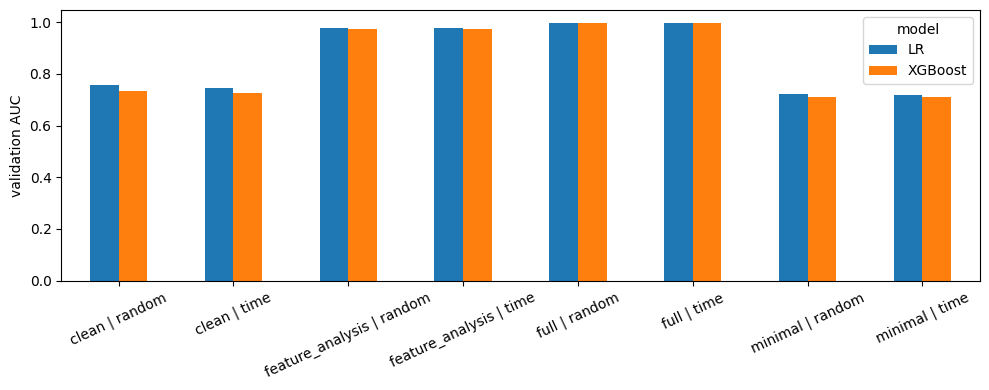

In [5]:
plot_df = res_profile[res_profile['model'].isin(['LR', 'XGBoost'])].copy()
plot_df['label'] = plot_df['feature_set'] + ' | ' + plot_df['split']
pivot_auc = plot_df.pivot(index='label', columns='model', values='val_roc_auc').sort_index()
ax = pivot_auc.plot.bar(figsize=(10, 4), rot=25, edgecolor='none')
ax.set_ylabel('validation AUC')
ax.set_xlabel('')
ax.figure.tight_layout()
ax.figure.savefig(out_dir / 'leakage_profile_auc.png', dpi=160)
display(pivot_auc.round(4))
plt.show()

## LOGO ablation on full, clean, and feature-analysis

Run leave-one-group-out ablation on the transformed matrix for `full`, `clean`, and `feature_analysis` with the random split so the three higher-signal surfaces can be compared directly.

In [6]:
def run_ablation(df_feat, split_idx):
    _, mats = transform_splits(df_feat, {'train': split_idx['train'], 'val': split_idx['val']}, pipe=build_pipeline())
    groups = feature_group_registry(mats['train'].columns)
    y_train = y.iloc[split_idx['train']].values
    y_val = y.iloc[split_idx['val']].values

    base_scores = {}
    for model_name, model in {'LR': LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs'), 'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.3, random_state=42, n_jobs=-1, verbosity=0)}.items():
        model.fit(mats['train'], y_train)
        base_scores[model_name] = evaluate_binary(model, mats['val'], y_val)

    rows = []
    for group_name, drop_cols in groups.items():
        if not drop_cols:
            continue
        mats_drop, present = ablate_matrix_group(mats, drop_cols)
        if not present:
            continue
        for model_name, model in {'LR': LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs'), 'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.3, random_state=42, n_jobs=-1, verbosity=0)}.items():
            model.fit(mats_drop['train'], y_train)
            metrics = evaluate_binary(model, mats_drop['val'], y_val)
            rows.append({
                'group': group_name,
                'model': model_name,
                'dropped_cols': len(present),
                'base_auc': base_scores[model_name]['roc_auc'],
                'val_auc': metrics['roc_auc'],
                'delta_auc': metrics['roc_auc'] - base_scores[model_name]['roc_auc'],
                'base_accuracy': base_scores[model_name]['accuracy'],
                'val_accuracy': metrics['accuracy'],
                'delta_accuracy': metrics['accuracy'] - base_scores[model_name]['accuracy'],
            })
    return pd.DataFrame(rows)

'full'

,group,model,dropped_cols,base_auc,val_auc,delta_auc,base_accuracy,val_accuracy,delta_accuracy
0,player_hero_wr,LR,14,0.9966,0.9921,-0.0045,0.9695,0.9515,-0.0180
1,cumulative_counts,LR,128,0.9966,0.9959,-0.0007,0.9695,0.9655,-0.0040
2,mmr,LR,51,0.9966,0.9961,-0.0005,0.9695,0.9683,-0.0012
3,hero_multihot,LR,76,0.9966,0.9966,-0.0000,0.9695,0.9685,-0.0010
4,global_hero_wr,LR,14,0.9966,0.9966,-0.0000,0.9695,0.9689,-0.0006
5,experience_gap,LR,3,0.9966,0.9966,-0.0000,0.9695,0.9688,-0.0007
6,global_hero_counts,LR,24,0.9966,0.9966,0.0000,0.9695,0.9692,-0.0003
7,accuracy,LR,24,0.9966,0.9966,0.0000,0.9695,0.9691,-0.0004
8,ending_level,LR,14,0.9966,0.9966,0.0001,0.9695,0.9695,0.0000
9,per_minute_rates,LR,190,0.9966,0.9967,0.0001,0.9695,0.9699,0.0004


model,LR,XGBoost
group,,
player_hero_wr,-0.0045,-0.0021
cumulative_counts,-0.0007,-0.0000
mmr,-0.0005,-0.0004
hero_multihot,-0.0000,0.0001
global_hero_wr,-0.0000,0.0001
experience_gap,-0.0000,0.0000
global_hero_counts,0.0000,0.0000
accuracy,0.0000,0.0000
ending_level,0.0001,0.0000


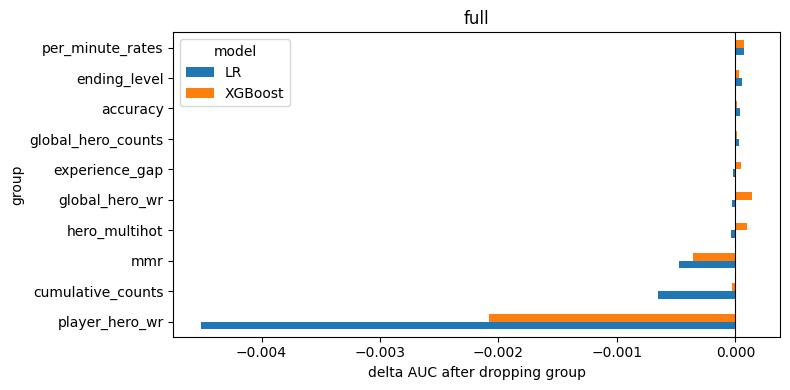

'clean'

,group,model,dropped_cols,base_auc,val_auc,delta_auc,base_accuracy,val_accuracy,delta_accuracy
0,accuracy,LR,24,0.7565,0.7096,-0.0469,0.6863,0.6561,-0.0302
1,mmr,LR,51,0.7565,0.7140,-0.0425,0.6863,0.6574,-0.0289
2,hero_multihot,LR,76,0.7565,0.7247,-0.0318,0.6863,0.6646,-0.0217
3,global_hero_wr,LR,14,0.7565,0.7565,0.0001,0.6863,0.6870,0.0007
4,global_hero_counts,LR,12,0.7565,0.7566,0.0001,0.6863,0.6880,0.0017
5,mmr,XGBoost,51,0.7343,0.6787,-0.0556,0.6701,0.6266,-0.0435
6,accuracy,XGBoost,24,0.7343,0.6963,-0.0380,0.6701,0.6512,-0.0189
7,hero_multihot,XGBoost,76,0.7343,0.7273,-0.0070,0.6701,0.6621,-0.0080
8,global_hero_wr,XGBoost,14,0.7343,0.7315,-0.0028,0.6701,0.6736,0.0035
9,global_hero_counts,XGBoost,12,0.7343,0.7335,-0.0008,0.6701,0.6659,-0.0042


model,LR,XGBoost
group,,
accuracy,-0.0469,-0.0380
mmr,-0.0425,-0.0556
hero_multihot,-0.0318,-0.0070
global_hero_wr,0.0001,-0.0028
global_hero_counts,0.0001,-0.0008


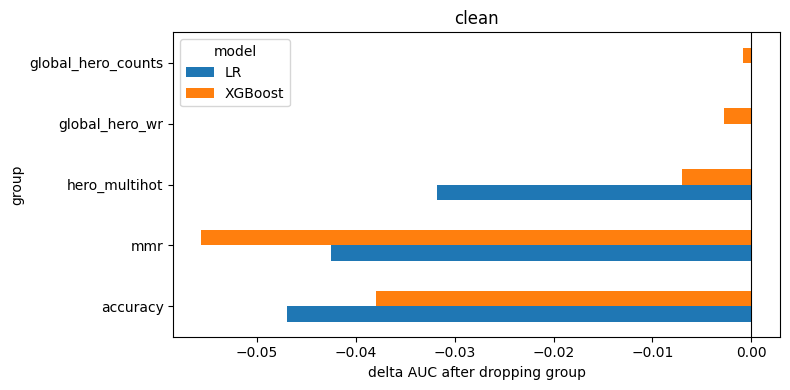

'feature_analysis'

,group,model,dropped_cols,base_auc,val_auc,delta_auc,base_accuracy,val_accuracy,delta_accuracy
0,per_minute_rates,LR,190,0.9774,0.7718,-0.2056,0.9185,0.7001,-0.2184
1,player_hero_wr,LR,14,0.9774,0.9666,-0.0108,0.9185,0.8989,-0.0196
2,cumulative_counts,LR,56,0.9774,0.9710,-0.0064,0.9185,0.9070,-0.0115
3,hero_multihot,LR,76,0.9774,0.9737,-0.0037,0.9185,0.9103,-0.0082
4,mmr,LR,51,0.9774,0.9761,-0.0013,0.9185,0.9165,-0.0020
5,experience_gap,LR,3,0.9774,0.9773,-0.0001,0.9185,0.9192,0.0007
6,global_hero_counts,LR,12,0.9774,0.9773,-0.0001,0.9185,0.9190,0.0005
7,accuracy,LR,24,0.9774,0.9774,0.0000,0.9185,0.9194,0.0009
8,global_hero_wr,LR,14,0.9774,0.9775,0.0001,0.9185,0.9184,-0.0001
9,per_minute_rates,XGBoost,190,0.9731,0.7561,-0.2171,0.9086,0.6887,-0.2199


model,LR,XGBoost
group,,
per_minute_rates,-0.2056,-0.2171
player_hero_wr,-0.0108,-0.0079
cumulative_counts,-0.0064,-0.0093
hero_multihot,-0.0037,-0.0010
mmr,-0.0013,-0.0018
experience_gap,-0.0001,0.0004
global_hero_counts,-0.0001,0.0001
accuracy,0.0000,0.0008
global_hero_wr,0.0001,0.0007


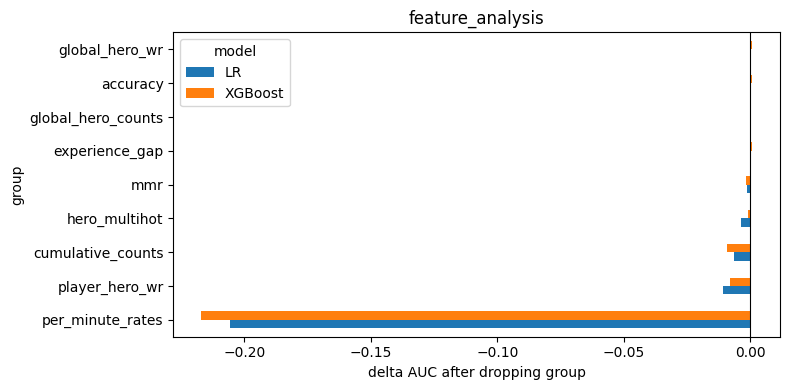

In [7]:
ablation_outputs = {}
for feature_name in ['full', 'clean', 'feature_analysis']:
    res_now = run_ablation(feature_frames[feature_name], splits['random'])
    res_now = res_now.sort_values(['model', 'delta_auc']).reset_index(drop=True)
    res_now.to_csv(out_dir / f'leakage_ablation_{feature_name}.csv', index=False)

    pivot_now = res_now.pivot(index='group', columns='model', values='delta_auc').sort_values('LR')
    fig, ax = plt.subplots(figsize=(8, 4))
    pivot_now.plot.barh(ax=ax, edgecolor='none')
    ax.set_xlabel('delta AUC after dropping group')
    ax.axvline(0.0, color='black', linewidth=0.8)
    ax.set_title(feature_name)
    fig.tight_layout()
    fig.savefig(out_dir / f'leakage_ablation_{feature_name}.png', dpi=160)

    display(feature_name)
    display(res_now.round(4))
    display(pivot_now.round(4))
    plt.show()

    ablation_outputs[feature_name] = {'res': res_now, 'pivot': pivot_now}

res_ablation_full = ablation_outputs['full']['res']
pivot_ablation_full = ablation_outputs['full']['pivot']
res_ablation_clean = ablation_outputs['clean']['res']
pivot_ablation_clean = ablation_outputs['clean']['pivot']
res_ablation = ablation_outputs['feature_analysis']['res']
pivot_ablation = ablation_outputs['feature_analysis']['pivot']